In [1]:
# Kaggle / Tesla P100 compatibility fix
# IMPORTANT: run this cell FIRST, before any other cell imports torch.
#
# Tesla P100 is a Pascal GPU (compute capability sm_60). PyTorch CUDA 12.8
# wheels no longer include sm_60 kernels, while the CUDA 12.6 build does.
# Pinning the CUDA 12.6 wheel avoids the "no kernel image is available" crash.

import subprocess
import sys

if "torch" in sys.modules:
    raise RuntimeError(
        "PyTorch has already been imported in this kernel. Restart the session/kernel, "
        "then run this first cell before running anything else."
    )

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--quiet",
    "--upgrade",
    "torch==2.8.0+cu126",
    "torchvision==0.23.0+cu126",
    "--index-url",
    "https://download.pytorch.org/whl/cu126",
])

print("Installed PyTorch 2.8.0 + CUDA 12.6 build (P100 / sm_60 compatible).")
print("Continue running the notebook from the next cell.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 236.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 142.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 194.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 89.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 112.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 157.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 150.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 131.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 95.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 117.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 132.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 219.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.8.0+cu126 which is incompatible.


Installed PyTorch 2.8.0 + CUDA 12.6 build (P100 / sm_60 compatible).
Continue running the notebook from the next cell.


# Auxiliary Segmentation Head for: Trustworthy Deep Learning for Chest X-ray Disease Detection
## Stage 2 - Candidate (b): Auxiliary Segmentation Head

Architecture : DenseNet121 (ImageNet-pretrained, timm) with 4-class classification head
               + auxiliary lung segmentation head

Dataset      : COVID-19 Radiography Database (Kaggle) - COVID / Normal / Lung_Opacity / Viral Pneumonia
               with corresponding lung masks

Split        : 70/15/15 stratified, fixed seed

Preprocessing: 224x224, 3-channel images, ImageNet normalization
               + binary lung masks

Augmentation : random rotation, horizontal flip, brightness/contrast jitter, random crop (train only)
               with spatial transformations applied consistently to images and masks

Optimizer    : AdamW (SGD-momentum / Adam selectable)

Loss         : Class-weighted cross-entropy classification loss
               + auxiliary segmentation loss

Training     : two-phase transfer learning (frozen backbone -> fine-tune final dense blocks)
               + auxiliary segmentation training
               + early stopping on validation loss

Evaluation   : accuracy, precision, recall, F1 (per-class + macro), ROC-AUC,
               confusion matrix, and lung segmentation performance

In [2]:
import argparse
import copy
import json
import os
import random
from pathlib import Path
 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score, accuracy_score

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from tqdm import tqdm

from PIL import Image
import torch.nn.functional as F
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
 
try:
    import timm
except ImportError as e:
    raise ImportError(
        "This script requires `timm`. Install with: pip install timm --break-system-packages"
    ) from e

## Reproducibility

In [3]:
def set_seed(seed: int = 42):
    """Set the random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Data

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [5]:
# Verify image-mask pairing before modifying the dataset pipeline

DATA_ROOT = Path(
    "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/"
    "COVID-19_Radiography_Dataset"
)

image_path = DATA_ROOT / "COVID" / "images" / "COVID-1.png"
mask_path = DATA_ROOT / "COVID" / "masks" / "COVID-1.png"

print("Image exists:", image_path.exists())
print("Mask exists :", mask_path.exists())

image = Image.open(image_path)
mask = Image.open(mask_path)

print("Image size:", image.size)
print("Mask size :", mask.size)
print("Image mode:", image.mode)
print("Mask mode :", mask.mode)

Image exists: True
Mask exists : True
Image size: (299, 299)
Mask size : (256, 256)
Image mode: L
Mask mode : RGB


After resize:
Image: (224, 224)
Mask : (224, 224)


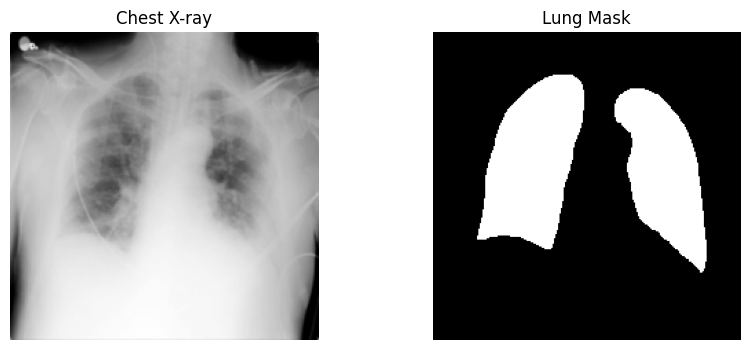

In [6]:
import matplotlib.pyplot as plt

# Load
image = Image.open(image_path).convert("L")
mask = Image.open(mask_path).convert("L")

# Resize both to the size we will use for training
image_224 = image.resize((224, 224), Image.BILINEAR)
mask_224 = mask.resize((224, 224), Image.NEAREST)

print("After resize:")
print("Image:", image_224.size)
print("Mask :", mask_224.size)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_224, cmap="gray")
plt.title("Chest X-ray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_224, cmap="gray")
plt.title("Lung Mask")
plt.axis("off")

plt.show()

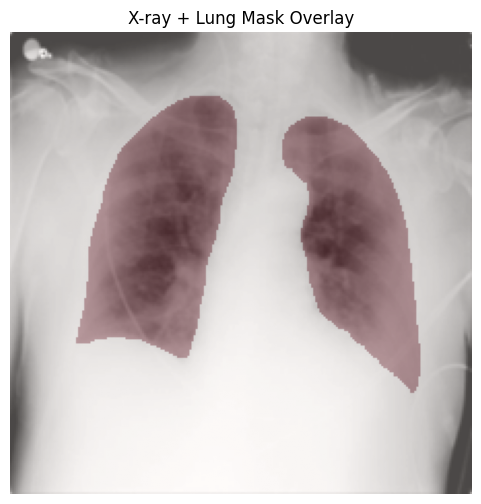

In [7]:
# Check whether the resized mask aligns with the lungs

plt.figure(figsize=(6, 6))

plt.imshow(image_224, cmap="gray")
plt.imshow(mask_224, cmap="Reds", alpha=0.3)

plt.title("X-ray + Lung Mask Overlay")
plt.axis("off")
plt.show()

In [8]:
class JointTransform:
    def __init__(self, img_size=224, train=True):
        self.img_size = img_size
        self.train = train

        self.color_jitter = transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2
        )

    def __call__(self, image, mask):

        # Resize image and mask to the same size
        image = TF.resize(
            image,
            [self.img_size, self.img_size],
            interpolation=InterpolationMode.BILINEAR
        )

        mask = TF.resize(
            mask,
            [self.img_size, self.img_size],
            interpolation=InterpolationMode.NEAREST
        )

        if self.train:

            # Pad before random crop
            image = TF.pad(
                image,
                padding=8,
                padding_mode="reflect"
            )

            mask = TF.pad(
                mask,
                padding=8,
                fill=0
            )

            # Same random crop for image and mask
            i, j, h, w = transforms.RandomCrop.get_params(
                image,
                output_size=(self.img_size, self.img_size)
            )

            image = TF.crop(image, i, j, h, w)
            mask = TF.crop(mask, i, j, h, w)

            # Same horizontal flip
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Same rotation
            angle = random.uniform(-10, 10)

            image = TF.rotate(
                image,
                angle,
                interpolation=InterpolationMode.BILINEAR
            )

            mask = TF.rotate(
                mask,
                angle,
                interpolation=InterpolationMode.NEAREST
            )

            # Brightness/contrast only affects image
            image = self.color_jitter(image)

        # X-ray -> 3 channels
        image = TF.to_grayscale(
            image,
            num_output_channels=3
        )

        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )

        # Mask -> grayscale binary tensor
        mask = TF.to_grayscale(
            mask,
            num_output_channels=1
        )

        mask = TF.to_tensor(mask)

        mask = (mask > 0.5).float()

        return image, mask

In [9]:
class CXRWithMaskDataset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = self.indices[idx]

        image_path, label = self.base_dataset.samples[base_idx]
        image_path = Path(image_path)

        # Matching mask:
        # COVID/images/COVID-1.png
        # COVID/masks/COVID-1.png
        mask_path = (
            image_path.parent.parent
            / "masks"
            / image_path.name
        )

        if not mask_path.exists():
            raise FileNotFoundError(
                f"Mask not found for: {image_path}\n"
                f"Expected mask: {mask_path}"
            )

        image = Image.open(image_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        image, mask = self.transform(image, mask)

        return image, label, mask

In [10]:
def stratified_split(dataset: ImageFolder, seed: int = 42):
  """70/15/15 stratified split of dataset into train, val, and test subsets."""

  targets = np.array(dataset.targets)
  indices = np.arange(len(dataset))

  train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, stratify=targets, random_state=seed
  )

  val_idx, test_idx = train_test_split(
    temp_idx,
    test_size= 0.50,
    stratify=targets[temp_idx],
    random_state = seed,
  )

  return train_idx, val_idx, test_idx

In [11]:
def build_dataloaders(
    data_dir: str,
    img_size: int,
    batch_size: int,
    seed: int,
    num_workers: int = 4
):
    # Only load files inside each class's "images" folder
    def only_images_folder(path):
        p = Path(path)
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

        return (
            p.parent.name.lower() == "images"
            and p.suffix.lower() in valid_exts
        )

    base_dataset = ImageFolder(
        root=data_dir,
        is_valid_file=only_images_folder
    )

    # Keep exactly the same 70/15/15 split as baseline
    train_idx, val_idx, test_idx = stratified_split(
        base_dataset,
        seed=seed
    )

    # Joint image + mask transformations
    train_tf = JointTransform(
        img_size=img_size,
        train=True
    )

    eval_tf = JointTransform(
        img_size=img_size,
        train=False
    )

    train_ds = CXRWithMaskDataset(
        base_dataset,
        train_idx,
        train_tf
    )

    val_ds = CXRWithMaskDataset(
        base_dataset,
        val_idx,
        eval_tf
    )

    test_ds = CXRWithMaskDataset(
        base_dataset,
        test_idx,
        eval_tf
    )

    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    class_names = base_dataset.classes

    train_targets = np.array(
        base_dataset.targets
    )[train_idx]

    datasets = {
        "train": train_ds,
        "val": val_ds,
        "test": test_ds
    }

    return (
        train_loader,
        val_loader,
        test_loader,
        class_names,
        train_targets,
        datasets
    )

In [12]:
test_train_loader, test_val_loader, test_test_loader, \
test_class_names, test_train_targets, test_datasets = build_dataloaders(
    data_dir=str(DATA_ROOT),
    img_size=224,
    batch_size=4,
    seed=42,
    num_workers=2
)

images, labels, masks = next(iter(test_train_loader))

print("Classes:", test_class_names)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Masks shape :", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype :", masks.dtype)

print("Mask min/max:", masks.min().item(), masks.max().item())

Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Images shape: torch.Size([4, 3, 224, 224])
Labels shape: torch.Size([4])
Masks shape : torch.Size([4, 1, 224, 224])
Image dtype: torch.float32
Mask dtype : torch.float32
Mask min/max: 0.0 1.0


In [13]:
def compute_class_weights(train_targets: np.ndarray, num_classes: int) -> torch.Tensor:
  counts = np.bincount(train_targets, minlength=num_classes).astype(np.float32)
  counts[counts == 0] = 1.0  # avoid div-by-zero
  weights = counts.sum() / (num_classes * counts)
  return torch.tensor(weights, dtype=torch.float32)

## Model

In [14]:
class DenseNetAuxSeg(nn.Module):
    """
    DenseNet121 disease classifier with a lightweight auxiliary
    lung-segmentation decoder.
    """
    def __init__(self, num_classes: int = 4):
        super().__init__()

        self.backbone = timm.create_model(
            "densenet121",
            pretrained=True,
            num_classes=num_classes
        )

        feature_channels = self.backbone.num_features  # 1024 for DenseNet121

        # DenseNet121 produces a 7x7 feature map for 224x224 inputs.
        # Five 2x upsampling steps reconstruct a 224x224 lung mask.
        self.seg_head = nn.Sequential(
            nn.Conv2d(feature_channels, 128, kernel_size=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(8, 1, kernel_size=1)
        )

    def forward(self, x):
        features = self.backbone.forward_features(x)

        # Original disease-classification branch
        class_logits = self.backbone.forward_head(features)

        # Auxiliary lung-segmentation branch
        mask_logits = self.seg_head(features)

        # Keep the mask output aligned to the actual input spatial size.
        if mask_logits.shape[-2:] != x.shape[-2:]:
            mask_logits = F.interpolate(
                mask_logits,
                size=x.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        return class_logits, mask_logits


def build_model(num_classes: int = 4) -> nn.Module:
    return DenseNetAuxSeg(num_classes=num_classes)


In [15]:
def freeze_backbone(model: nn.Module):
    """
    Phase 1:
      - freeze DenseNet feature extraction
      - train the classification head
      - train the new auxiliary segmentation head
    """
    for param in model.backbone.parameters():
        param.requires_grad = False

    for param in model.backbone.get_classifier().parameters():
        param.requires_grad = True

    for param in model.seg_head.parameters():
        param.requires_grad = True


def print_trainable_parameters(model: nn.Module):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    print(f"Trainable parameters: {trainable:,}")
    print(f"Total parameters:     {total:,}")
    print(f"Trainable percentage: {100.0 * trainable / total:.2f}%")


In [16]:
def unfreeze_final_blocks(model: nn.Module, num_dense_blocks_to_unfreeze: int = 1):
    """
    Phase 2:
      - keep early DenseNet layers frozen
      - unfreeze the final N dense blocks
      - keep classification and segmentation heads trainable

    num_dense_blocks_to_unfreeze must be between 1 and 4.
    """
    if not 1 <= num_dense_blocks_to_unfreeze <= 4:
        raise ValueError("num_dense_blocks_to_unfreeze must be between 1 and 4.")

    # Start from a fully frozen model.
    for param in model.parameters():
        param.requires_grad = False

    # Both task heads must remain trainable.
    for param in model.backbone.get_classifier().parameters():
        param.requires_grad = True

    for param in model.seg_head.parameters():
        param.requires_grad = True

    features = model.backbone.features

    # Final normalization belongs to the fine-tuned tail.
    for param in features.norm5.parameters():
        param.requires_grad = True

    # Unfreeze dense blocks from the end: 4, 3, 2, 1.
    selected_blocks = list(range(4, 4 - num_dense_blocks_to_unfreeze, -1))

    for block_idx in selected_blocks:
        dense_block = getattr(features, f"denseblock{block_idx}")
        for param in dense_block.parameters():
            param.requires_grad = True

    # If more than one dense block is unfrozen, also unfreeze the
    # transition layers that connect the selected blocks.
    for transition_idx in range(4 - num_dense_blocks_to_unfreeze + 1, 4):
        transition = getattr(features, f"transition{transition_idx}")
        for param in transition.parameters():
            param.requires_grad = True


In [17]:
def build_optimizer(model, name: str, lr: float, weight_decay: float):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if name == "adamw":
        return torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    elif name == "adam":
        return torch.optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
    elif name == "sgd":
        return torch.optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")

In [18]:
def build_scheduler(optimizer, name: str, epochs: int):
    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif name == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)
    elif name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)
    elif name == "none":
        return None
    raise ValueError(f"Unknown scheduler: {name}")

## Training / evaluation loops

In [19]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        dims = (1, 2, 3)
        intersection = (probs * targets).sum(dim=dims)
        denominator = probs.sum(dim=dims) + targets.sum(dim=dims)

        dice = (
            (2.0 * intersection + self.smooth)
            / (denominator + self.smooth)
        )

        return 1.0 - dice.mean()


dice_loss_fn = DiceLoss()
bce_loss_fn = nn.BCEWithLogitsLoss()


def compute_multitask_loss(
    class_logits,
    mask_logits,
    labels,
    masks,
    classification_criterion,
    lambda_seg: float = 0.3,
):
    """
    Segmentation loss = 0.5 * BCE + 0.5 * Dice
    Total loss        = classification loss + lambda_seg * segmentation loss
    """
    cls_loss = classification_criterion(class_logits, labels)

    bce_loss = bce_loss_fn(mask_logits, masks)
    dice_loss = dice_loss_fn(mask_logits, masks)
    seg_loss = 0.5 * bce_loss + 0.5 * dice_loss

    total_loss = cls_loss + lambda_seg * seg_loss

    return total_loss, cls_loss, seg_loss


def run_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    train: bool,
    lambda_seg: float = 0.3,
    desc: str = "",
    scaler=None,
):
    model.train() if train else model.eval()

    total_loss = 0.0
    total_cls_loss = 0.0
    total_seg_loss = 0.0
    correct = 0
    total = 0

    non_blocking = device.type == "cuda"
    context = torch.enable_grad() if train else torch.no_grad()
    progress = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)

    with context:
        for images, labels, masks in progress:
            images = images.to(device, non_blocking=non_blocking)
            labels = labels.to(device, non_blocking=non_blocking).long()
            masks = masks.to(device, non_blocking=non_blocking).float()

            if masks.ndim == 3:
                masks = masks.unsqueeze(1)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                enabled=(device.type == "cuda"),
            ):
                class_logits, mask_logits = model(images)

                loss, cls_loss, seg_loss = compute_multitask_loss(
                    class_logits,
                    mask_logits,
                    labels,
                    masks,
                    criterion,
                    lambda_seg=lambda_seg,
                )

            if train:
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            batch_size = images.size(0)

            total_loss += loss.item() * batch_size
            total_cls_loss += cls_loss.item() * batch_size
            total_seg_loss += seg_loss.item() * batch_size

            preds = class_logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

            progress.set_postfix(
                loss=f"{total_loss / total:.4f}",
                cls=f"{total_cls_loss / total:.4f}",
                seg=f"{total_seg_loss / total:.4f}",
                acc=f"{correct / total:.4f}",
            )

    return {
        "loss": total_loss / total,
        "cls_loss": total_cls_loss / total,
        "seg_loss": total_seg_loss / total,
        "accuracy": correct / total,
    }


In [20]:
def train_phase(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
    patience,
    phase_name,
    output_dir,
    lambda_seg: float = 0.3,
):
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    history = []

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(device.type == "cuda")
    )

    for epoch in range(1, epochs + 1):
        train_desc = f"{phase_name} epoch {epoch}/{epochs} train"
        val_desc = f"{phase_name} epoch {epoch}/{epochs} val"

        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            train=True,
            lambda_seg=lambda_seg,
            desc=train_desc,
            scaler=scaler,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer,
            device,
            train=False,
            lambda_seg=lambda_seg,
            desc=val_desc,
        )

        if scheduler is not None:
            if isinstance(
                scheduler,
                torch.optim.lr_scheduler.ReduceLROnPlateau
            ):
                scheduler.step(val_metrics["loss"])
            else:
                scheduler.step()

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_cls_loss": train_metrics["cls_loss"],
            "train_seg_loss": train_metrics["seg_loss"],
            "train_acc": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_cls_loss": val_metrics["cls_loss"],
            "val_seg_loss": val_metrics["seg_loss"],
            "val_acc": val_metrics["accuracy"],
        }
        history.append(row)

        print(
            f"[{phase_name}] epoch {epoch}/{epochs} "
            f"train_loss={train_metrics['loss']:.4f} "
            f"(cls={train_metrics['cls_loss']:.4f}, seg={train_metrics['seg_loss']:.4f}) "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} "
            f"(cls={val_metrics['cls_loss']:.4f}, seg={val_metrics['seg_loss']:.4f}) "
            f"val_acc={val_metrics['accuracy']:.4f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(
                    f"[{phase_name}] Early stopping at epoch {epoch} "
                    f"(no improvement for {patience} epochs)."
                )
                break

    model.load_state_dict(best_state)

    with open(Path(output_dir) / f"{phase_name}_history.json", "w") as f:
        json.dump(history, f, indent=2)

    return model


In [21]:
@torch.no_grad()
def evaluate(model, loader, class_names, device, output_dir, evaluation_type):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []
    dice_scores = []
    iou_scores = []

    non_blocking = device.type == "cuda"
    eps = 1e-6

    for images, labels, masks in loader:
        images = images.to(device, non_blocking=non_blocking)
        masks = masks.to(device, non_blocking=non_blocking).float()

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        class_logits, mask_logits = model(images)

        probs = torch.softmax(class_logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

        pred_masks = (torch.sigmoid(mask_logits) >= 0.5).float()

        dims = (1, 2, 3)
        intersection = (pred_masks * masks).sum(dim=dims)
        pred_sum = pred_masks.sum(dim=dims)
        target_sum = masks.sum(dim=dims)

        dice = (2.0 * intersection + eps) / (
            pred_sum + target_sum + eps
        )

        union = pred_sum + target_sum - intersection
        iou = (intersection + eps) / (union + eps)

        dice_scores.extend(dice.cpu().numpy())
        iou_scores.extend(iou.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4,
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(all_labels, all_preds)

    try:
        auc_macro = roc_auc_score(
            all_labels,
            all_probs,
            multi_class="ovr",
            average="macro",
        )
        auc_per_class = roc_auc_score(
            all_labels,
            all_probs,
            multi_class="ovr",
            average=None,
        )
    except ValueError:
        auc_macro, auc_per_class = None, None

    mean_dice = float(np.mean(dice_scores))
    mean_iou = float(np.mean(iou_scores))

    results = {
        "classification_report": report,
        "confusion_matrix": cm.tolist(),
        "roc_auc_macro": auc_macro,
        "roc_auc_per_class": (
            auc_per_class.tolist()
            if auc_per_class is not None
            else None
        ),
        "segmentation_dice": mean_dice,
        "segmentation_iou": mean_iou,
        "class_names": class_names,
    }

    with open(
        Path(output_dir) / f"{evaluation_type}_test_results.json",
        "w",
    ) as f:
        json.dump(results, f, indent=2)

    print("\n=== Test set performance ===")
    print(f"Test accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            digits=4,
            zero_division=0,
        )
    )
    print("Confusion matrix:\n", cm)

    if auc_macro is not None:
        print(f"Macro ROC-AUC: {auc_macro:.4f}")

    print(f"Segmentation Dice: {mean_dice:.4f}")
    print(f"Segmentation IoU : {mean_iou:.4f}")

    cm_df = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )
    cm_df.to_csv(
        Path(output_dir)
        / f"{evaluation_type}_confusion_matrix.csv"
    )

    summary = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "macro_f1": report["macro avg"]["f1-score"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_precision": report["macro avg"]["precision"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "weighted_recall": report["weighted avg"]["recall"],
        "roc_auc_macro": auc_macro,
        "segmentation_dice": mean_dice,
        "segmentation_iou": mean_iou,
    }

    pd.DataFrame([summary]).to_csv(
        Path(output_dir)
        / f"{evaluation_type}_summary_metrics.csv",
        index=False,
    )

    return results


In [22]:
parser = argparse.ArgumentParser(
    description="DenseNet121 + Auxiliary Segmentation Head - Stage 2 Candidate (b)"
)

parser.add_argument(
    "--data_dir",
    type=str,
    default=(
        "/kaggle/input/datasets/tawsifurrahman/"
        "covid19-radiography-database/"
        "COVID-19_Radiography_Dataset"
    ),
    help="Path to the COVID-19 Radiography Dataset root",
)

parser.add_argument(
    "--output_dir",
    type=str,
    default="./runs/densenet121_auxseg",
)

parser.add_argument("--img_size", type=int, default=224)
parser.add_argument("--batch_size", type=int, default=32)
parser.add_argument("--seed", type=int, default=42)
parser.add_argument("--num_workers", type=int, default=4)

parser.add_argument(
    "--device",
    type=str,
    default="auto",
    choices=["auto", "cuda", "cpu"],
    help="'auto' picks CUDA if available, else CPU.",
)

# Auxiliary segmentation contribution:
# total_loss = classification_loss + lambda_seg * segmentation_loss
parser.add_argument("--lambda_seg", type=float, default=0.3)

# Phase 1: DenseNet feature extractor frozen, both heads trained
parser.add_argument("--phase1_epochs", type=int, default=15)
parser.add_argument("--phase1_lr", type=float, default=1e-3)

# Phase 2: fine-tune final DenseNet block(s) + both heads
parser.add_argument("--phase2_epochs", type=int, default=40)
parser.add_argument("--phase2_lr", type=float, default=1e-5)
parser.add_argument(
    "--unfreeze_blocks",
    type=int,
    default=1,
    choices=[1, 2, 3, 4],
)

# Hyperparameter-sweep knobs
parser.add_argument(
    "--optimizer",
    type=str,
    default="adamw",
    choices=["adamw", "adam", "sgd"],
)

parser.add_argument("--weight_decay", type=float, default=1e-4)

parser.add_argument(
    "--scheduler",
    type=str,
    default="cosine",
    choices=["cosine", "step", "plateau", "none"],
)

parser.add_argument("--patience", type=int, default=5)


_StoreAction(option_strings=['--patience'], dest='patience', nargs=None, const=None, default=5, type=<class 'int'>, choices=None, required=False, help=None, metavar=None)

In [23]:
args, _ = parser.parse_known_args()

Path(args.output_dir).mkdir(parents=True, exist_ok=True)
set_seed(args.seed)

In [24]:
# ---- Device selection + CUDA compatibility check ----

def _cuda_build_supports_current_gpu():
    """Return (supported, arch, built_arches) for CUDA device 0."""
    if not torch.cuda.is_available():
        return False, None, []

    major, minor = torch.cuda.get_device_capability(0)
    arch = f"sm_{major}{minor}"
    built_arches = list(torch.cuda.get_arch_list())
    return arch in built_arches, arch, built_arches


cuda_available = torch.cuda.is_available()
cuda_supported, gpu_arch, built_arches = _cuda_build_supports_current_gpu()

if args.device == "cuda" and not cuda_available:
    raise RuntimeError("--device cuda was requested but no CUDA GPU is available.")

# If a CUDA GPU exists but this PyTorch binary has no kernels for it, stop early
# rather than failing later inside the first DenseNet convolution.
if cuda_available and not cuda_supported:
    gpu_name = torch.cuda.get_device_name(0)
    raise RuntimeError(
        f"GPU {gpu_name} ({gpu_arch}) is not supported by the installed "
        f"PyTorch build {torch.__version__}. Built CUDA architectures: {built_arches}. "
        "Run the FIRST notebook cell to install the CUDA 12.6 PyTorch build, then "
        "restart/rerun the notebook from the top if needed."
    )

if args.device == "auto":
    device = torch.device("cuda" if cuda_available else "cpu")
else:
    device = torch.device(args.device)

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Compute capability: {gpu_arch}")
    print(f"  CUDA runtime in PyTorch: {torch.version.cuda}")
    print(f"  PyTorch built architectures: {built_arches}")
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"  GPU memory: {total_mem_gb:.1f} GB")

    # Tiny real CUDA-kernel test. This catches binary/GPU incompatibility before
    # the expensive training loop starts.
    with torch.no_grad():
        _test_conv = nn.Conv2d(3, 4, kernel_size=3, padding=1).to(device)
        _test_x = torch.randn(1, 3, 32, 32, device=device)
        _ = _test_conv(_test_x)
        torch.cuda.synchronize()
    del _test_conv, _test_x, _
    print("  CUDA convolution smoke test: PASSED")
else:
    print(
        "  Running on CPU - training DenseNet121 will be much slower. "
        "Use a GPU runtime for the full experiment."
    )

Using device: cuda
PyTorch version: 2.8.0+cu126
  GPU: Tesla T4
  Compute capability: sm_75
  CUDA runtime in PyTorch: 12.6
  PyTorch built architectures: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
  GPU memory: 14.6 GB
  CUDA convolution smoke test: PASSED


In [25]:
# ---- Data ----
train_loader, val_loader, test_loader, class_names, train_targets, datasets = build_dataloaders(
    args.data_dir,
    args.img_size,
    args.batch_size,
    args.seed,
    args.num_workers,
)

num_classes = len(class_names)

print(f"Classes ({num_classes}): {class_names}")
print(
    f"Train/Val/Test sizes: "
    f"{len(train_loader.dataset)}/"
    f"{len(val_loader.dataset)}/"
    f"{len(test_loader.dataset)}"
)

class_weights = compute_class_weights(
    train_targets,
    num_classes
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Class weights:", class_weights.detach().cpu().numpy())
print(f"Auxiliary segmentation weight (lambda_seg): {args.lambda_seg}")


Classes (4): ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train/Val/Test sizes: 14815/3175/3175
Class weights: [1.4633543  0.88016874 0.5191688  3.9317942 ]
Auxiliary segmentation weight (lambda_seg): 0.3


## Cache preprocessed images (optional)

Writes the fully preprocessed (resize + grayscale + normalize) images to disk as PNGs, one folder per split/class, so the expensive PIL decode/resize doesn't have to be repeated on every epoch or run.

Note: the train split's random augmentation (crop/flip/rotation/jitter) is intentionally **not** baked into this cache — that transform is meant to produce a different result each epoch, so caching one fixed draw of it would silently remove that variability. The train images below are cached with the same deterministic transform used for val/test.

In [26]:
def cache_preprocessed_images(
    dataset,
    class_names,
    split_name: str,
    output_dir,
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
):
    """
    Optional utility: save the preprocessed X-ray tensors as viewable PNGs.
    The auxiliary mask returned by the dataset is ignored here.
    """
    split_dir = Path(output_dir) / split_name

    for cls in class_names:
        (split_dir / cls).mkdir(parents=True, exist_ok=True)

    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    to_pil = transforms.ToPILImage()

    counts = {cls: 0 for cls in class_names}

    for img_tensor, label, _mask in tqdm(
        dataset,
        desc=f"Caching {split_name}",
        dynamic_ncols=True,
    ):
        cls = class_names[label]

        denorm = (
            img_tensor * std_t + mean_t
        ).clamp(0, 1)

        to_pil(denorm).save(
            split_dir / cls / f"{counts[cls]:05d}.png"
        )

        counts[cls] += 1

    print(
        f"[{split_name}] cached "
        f"{sum(counts.values())} images to {split_dir}"
    )

    return counts


In [27]:
# Optional deterministic preprocessing cache.
# Set to True only if you actually want PNG copies written to disk.
CACHE_PREPROCESSED = False

if CACHE_PREPROCESSED:
    train_ds_deterministic = CXRWithMaskDataset(
        datasets["train"].base_dataset,
        datasets["train"].indices,
        JointTransform(
            img_size=args.img_size,
            train=False,
        ),
    )

    cache_dir = (
        Path(args.output_dir)
        / "preprocessed_images"
    )

    cache_preprocessed_images(
        train_ds_deterministic,
        class_names,
        "train",
        cache_dir,
    )

    cache_preprocessed_images(
        datasets["val"],
        class_names,
        "val",
        cache_dir,
    )

    cache_preprocessed_images(
        datasets["test"],
        class_names,
        "test",
        cache_dir,
    )
else:
    print("Skipping optional preprocessed-image cache.")


Skipping optional preprocessed-image cache.


In [28]:
model = build_model(num_classes=num_classes).to(device)

print(model.__class__.__name__)
print_trainable_parameters(model)


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

DenseNetAuxSeg
Trainable parameters: 7,187,701
Total parameters:     7,187,701
Trainable percentage: 100.00%


In [29]:
# ---- Phase 1: frozen DenseNet feature extractor ----
freeze_backbone(model)
print("\nPhase 1 trainable parameters:")
print_trainable_parameters(model)

opt1 = build_optimizer(
    model,
    args.optimizer,
    args.phase1_lr,
    args.weight_decay,
)

sched1 = build_scheduler(
    opt1,
    args.scheduler,
    args.phase1_epochs,
)

model = train_phase(
    model,
    train_loader,
    val_loader,
    criterion,
    opt1,
    sched1,
    device,
    args.phase1_epochs,
    args.patience,
    "phase1_frozen",
    args.output_dir,
    lambda_seg=args.lambda_seg,
)



Phase 1 trainable parameters:
Trainable parameters: 233,845
Total parameters:     7,187,701
Trainable percentage: 3.25%


[phase1_frozen] epoch 1/15 train_loss=0.7163 (cls=0.6224, seg=0.3129) train_acc=0.7328 | val_loss=0.5050 (cls=0.4555, seg=0.1653) val_acc=0.7978


[phase1_frozen] epoch 2/15 train_loss=0.4940 (cls=0.4539, seg=0.1338) train_acc=0.8012 | val_loss=0.4425 (cls=0.4087, seg=0.1129) val_acc=0.8350


[phase1_frozen] epoch 3/15 train_loss=0.4399 (cls=0.4071, seg=0.1094) train_acc=0.8178 | val_loss=0.4142 (cls=0.3818, seg=0.1081) val_acc=0.8494


[phase1_frozen] epoch 4/15 train_loss=0.4286 (cls=0.3981, seg=0.1019) train_acc=0.8223 | val_loss=0.4288 (cls=0.3998, seg=0.0965) val_acc=0.8529


...

[phase1_frozen] epoch 11/15 train_loss=0.3652 (cls=0.3390, seg=0.0872) train_acc=0.8470 | val_loss=0.3558 (cls=0.3303, seg=0.0849) val_acc=0.8598


[phase1_frozen] epoch 12/15 train_loss=0.3632 (cls=0.3374, seg=0.0860) train_acc=0.8508 | val_loss=0.3692 (cls=0.3437, seg=0.0850) val_acc=0.8630


[phase1_frozen] epoch 13/15 train_loss=0.3606 (cls=0.3350, seg=0.0854) train_acc=0.8501 | val_loss=0.3636 (cls=0.3385, seg=0.0838) val_acc=0.8693


[phase1_frozen] epoch 14/15 train_loss=0.3603 (cls=0.3349, seg=0.0849) train_acc=0.8486 | val_loss=0.3578 (cls=0.3326, seg=0.0837) val_acc=0.8677


[phase1_frozen] epoch 15/15 train_loss=0.3532 (cls=0.3279, seg=0.0845) train_acc=0.8538 | val_loss=0.3599 (cls=0.3348, seg=0.0836) val_acc=0.8696


In [30]:
# Optional checkpoint evaluation after Phase 1
evaluate(
    model,
    test_loader,
    class_names,
    device,
    args.output_dir,
    "phase1_frozen",
)



=== Test set performance ===
Test accuracy: 0.8592
                 precision    recall  f1-score   support

          COVID     0.8378    0.8007    0.8189       542
   Lung_Opacity     0.8147    0.8625    0.8379       902
         Normal     0.9018    0.8653    0.8832      1529
Viral Pneumonia     0.8213    0.9554    0.8833       202

       accuracy                         0.8592      3175
      macro avg     0.8439    0.8710    0.8558      3175
   weighted avg     0.8610    0.8592    0.8593      3175

Confusion matrix:
 [[ 434   48   52    8]
 [  38  778   84    2]
 [  45  129 1323   32]
 [   1    0    8  193]]
Macro ROC-AUC: 0.9726
Segmentation Dice: 0.9277
Segmentation IoU : 0.8672


{'classification_report': {'COVID': {'precision': 0.8378378378378378,
   'recall': 0.8007380073800738,
   'f1-score': 0.8188679245283019,
   'support': 542.0},
  'Lung_Opacity': {'precision': 0.8146596858638744,
   'recall': 0.8625277161862528,
   'f1-score': 0.8379106085083468,
   'support': 902.0},
  'Normal': {'precision': 0.901840490797546,
   'recall': 0.8652714192282538,
   'f1-score': 0.883177570093458,
   'support': 1529.0},
  'Viral Pneumonia': {'precision': 0.8212765957446808,
   'recall': 0.9554455445544554,
   'f1-score': 0.8832951945080092,
   'support': 202.0},
  'accuracy': 0.8592125984251968,
  'macro avg': {'precision': 0.8439036525609848,
   'recall': 0.870995671837259,
   'f1-score': 0.855812824409529,
   'support': 3175.0},
  'weighted avg': {'precision': 0.8610214574888807,
   'recall': 0.8592125984251968,
   'f1-score': 0.8593467458054751,
   'support': 3175.0}},
 'confusion_matrix': [[434, 48, 52, 8],
  [38, 778, 84, 2],
  [45, 129, 1323, 32],
  [1, 0, 8, 193]],


In [31]:
# ---- Phase 2: fine-tune final DenseNet block(s) ----
unfreeze_final_blocks(
    model,
    num_dense_blocks_to_unfreeze=args.unfreeze_blocks,
)

print("\nPhase 2 trainable parameters:")
print_trainable_parameters(model)

opt2 = build_optimizer(
    model,
    args.optimizer,
    args.phase2_lr,
    args.weight_decay,
)

sched2 = build_scheduler(
    opt2,
    args.scheduler,
    args.phase2_epochs,
)

model = train_phase(
    model,
    train_loader,
    val_loader,
    criterion,
    opt2,
    sched2,
    device,
    args.phase2_epochs,
    args.patience,
    "phase2_finetune",
    args.output_dir,
    lambda_seg=args.lambda_seg,
)



Phase 2 trainable parameters:
Trainable parameters: 2,393,973
Total parameters:     7,187,701
Trainable percentage: 33.31%


[phase2_finetune] epoch 1/40 train_loss=0.3496 (cls=0.3239, seg=0.0857) train_acc=0.8523 | val_loss=0.3588 (cls=0.3336, seg=0.0843) val_acc=0.8737


[phase2_finetune] epoch 2/40 train_loss=0.3449 (cls=0.3192, seg=0.0855) train_acc=0.8589 | val_loss=0.3471 (cls=0.3218, seg=0.0845) val_acc=0.8690


[phase2_finetune] epoch 3/40 train_loss=0.3474 (cls=0.3218, seg=0.0852) train_acc=0.8578 | val_loss=0.3444 (cls=0.3191, seg=0.0843) val_acc=0.8715


[phase2_finetune] epoch 4/40 train_loss=0.3340 (cls=0.3084, seg=0.0852) train_acc=0.8614 | val_loss=0.3457 (cls=0.3205, seg=0.0839) val_acc=0.8762


...

[phase2_finetune] epoch 32/40 train_loss=0.2570 (cls=0.2317, seg=0.0842) train_acc=0.8945 | val_loss=0.2880 (cls=0.2630, seg=0.0835) val_acc=0.8970


[phase2_finetune] epoch 33/40 train_loss=0.2579 (cls=0.2326, seg=0.0841) train_acc=0.8941 | val_loss=0.2915 (cls=0.2665, seg=0.0834) val_acc=0.8970


[phase2_finetune] epoch 34/40 train_loss=0.2580 (cls=0.2327, seg=0.0843) train_acc=0.8942 | val_loss=0.2894 (cls=0.2643, seg=0.0835) val_acc=0.8970


[phase2_finetune] epoch 35/40 train_loss=0.2542 (cls=0.2289, seg=0.0843) train_acc=0.8938 | val_loss=0.2860 (cls=0.2609, seg=0.0837) val_acc=0.8948


[phase2_finetune] epoch 36/40 train_loss=0.2586 (cls=0.2334, seg=0.0839) train_acc=0.8944 | val_loss=0.2871 (cls=0.2620, seg=0.0837) val_acc=0.8945
[phase2_finetune] Early stopping at epoch 36 (no improvement for 5 epochs).


In [32]:
ckpt_path = (
    Path(args.output_dir)
    / "densenet121_auxseg.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "lambda_seg": args.lambda_seg,
        "unfreeze_blocks": args.unfreeze_blocks,
    },
    ckpt_path,
)

print(f"Saved checkpoint to {ckpt_path}")


Saved checkpoint to runs/densenet121_auxseg/densenet121_auxseg.pt


In [33]:
# ---- Final evaluation on the held-out test set ----
final_results = evaluate(
    model,
    test_loader,
    class_names,
    device,
    args.output_dir,
    "phase2_finetune",
)



=== Test set performance ===
Test accuracy: 0.9002
                 precision    recall  f1-score   support

          COVID     0.9043    0.8893    0.8967       542
   Lung_Opacity     0.8915    0.8559    0.8733       902
         Normal     0.9034    0.9235    0.9133      1529
Viral Pneumonia     0.9014    0.9505    0.9253       202

       accuracy                         0.9002      3175
      macro avg     0.9001    0.9048    0.9022      3175
   weighted avg     0.9000    0.9002    0.8999      3175

Confusion matrix:
 [[ 482   20   37    3]
 [  24  772  104    2]
 [  27   74 1412   16]
 [   0    0   10  192]]
Macro ROC-AUC: 0.9832
Segmentation Dice: 0.9287
Segmentation IoU : 0.8689
